In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm
from utils import rnmse
from torch.utils.data import DataLoader, TensorDataset
from sklearn.base import BaseEstimator
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Subset
from neuralop import FNO
import pandas as pd
import seaborn as sns
import matplotlib
sns.set_style('whitegrid')
sns.set_context('notebook')
sns.set_palette('hot', n_colors=7)
plt.rc('text', usetex=True)      

font = {'family' : 'serif',
        'weight' : 'bold',
        'size'   : 22}

matplotlib.rc('font', **font)

plt.rc('xtick',labelsize=12)
plt.rc('ytick',labelsize=12)

Error: trying to import DISCO convolutions without optional dependency torch-harmonics.  Please install with `pip install torch-harmonics` and retry.


In [56]:
x = torch.cat([torch.load("../dataset_fd/x_div_1_train.pt"), torch.load("../dataset_fd/x_div_1_train_2.pt")])
y = torch.cat([torch.load("../dataset/x_train.pt"), torch.load("../dataset/x_train_2.pt")])

In [36]:
x.shape

torch.Size([27000, 256, 128])

In [37]:
x_np, y_np = x.numpy(), y.numpy()
x_np_reshaped, y_np_reshaped = x_np.reshape((x_np.shape[0], -1)), y_np.reshape((y_np.shape[0], -1))

In [38]:
class DoNothingRegressor(BaseEstimator):
    def __init__(self):
        pass
    def fit(self, X, y):
        pass
    def predict(self, X):
        return np.zeros_like(X)

In [39]:
class VanillaRegressor(BaseEstimator):
    def __init__(self, regressor, n_components=64):
        self.regressor = regressor
        self.n_components = n_components
        self.pipe = TransformedTargetRegressor(
            regressor=Pipeline([
                ("pca", PCA(n_components=self.n_components)),
                ("reg", self.regressor)
            ]),
            transformer=PCA(n_components=self.n_components),
            check_inverse=False
        )

    def fit(self, X, y):
        self.pipe.fit(X, y)

    def predict(self, X):
        return self.pipe.predict(X)

In [40]:
class ResidualRegressor(BaseEstimator):
    def __init__(self, regressor, n_components=64):
        self.n_components = n_components
        self.pipe_lm = TransformedTargetRegressor(
            regressor=Pipeline([
                ("pca", PCA(n_components=self.n_components)),
                ("lm", LinearRegression(n_jobs=-1))
            ]),
            transformer=PCA(n_components=self.n_components),
            check_inverse=False
        )
        self.regressor = regressor

    def fit(self, X, y):
        self.pipe_lm.fit(X, y)
        y_hat_lm = self.pipe_lm.predict(X)
        self.regressor.fit(X, y-y_hat_lm)

    def predict(self, X):
        return self.regressor.predict(X) + self.pipe_lm.predict(X)

In [41]:
def scorer_rnmse(estimator, x, y):
    return rnmse(estimator.predict(x), y)

In [42]:
n_points = 1024#x.shape[0]
n_cv = 5
n_epochs = 500
n_components_pca = 8#512
scores = {}

In [43]:
scores["Residual PCR"] = cross_val_score(
    ResidualRegressor(DoNothingRegressor(), n_components_pca),
    x_np_reshaped[:n_points], y_np_reshaped[:n_points],
    cv=n_cv,
    scoring=scorer_rnmse,
    n_jobs=-1,
    verbose=1
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    3.8s remaining:    5.8s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    3.9s finished


In [44]:
scores["Vanilla LM"] = cross_val_score(
    VanillaRegressor(TransformedTargetRegressor(
            regressor=Pipeline([
                ("pca", PCA(n_components=n_components_pca)),
                ("lm", LinearRegression(n_jobs=-1))
            ]),
            transformer=PCA(n_components=n_components_pca),
            check_inverse=False
        ), n_components_pca),
    x_np_reshaped[:n_points], y_np_reshaped[:n_points],
    cv=n_cv,
    scoring=scorer_rnmse,
    n_jobs=-1,
    verbose=1
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    2.1s remaining:    3.2s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    2.2s finished


In [45]:
from sklearn.neighbors import KNeighborsRegressor
scores["Residual KNN"] = cross_val_score(
    ResidualRegressor(TransformedTargetRegressor(
            regressor=Pipeline([
                ("pca", PCA(n_components=n_components_pca)),
                ("knn", KNeighborsRegressor(10))
            ]),
            transformer=PCA(n_components=n_components_pca),
            check_inverse=False
        ), n_components_pca),
    x_np_reshaped[:n_points], y_np_reshaped[:n_points],
    cv=n_cv,
    scoring=scorer_rnmse,
    n_jobs=-1,
    verbose=1
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    4.1s remaining:    6.1s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    4.2s finished


In [46]:
from sklearn.neighbors import KNeighborsRegressor
scores["Vanilla KNN"] = cross_val_score(
    VanillaRegressor(TransformedTargetRegressor(
            regressor=Pipeline([
                ("pca", PCA(n_components=n_components_pca)),
                ("knn", KNeighborsRegressor(10))
            ]),
            transformer=PCA(n_components=n_components_pca),
            check_inverse=False
        ), n_components_pca),
    x_np_reshaped[:n_points], y_np_reshaped[:n_points],
    cv=n_cv,
    scoring=scorer_rnmse,
    n_jobs=-1,
    verbose=1
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    2.0s remaining:    3.1s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    2.1s finished


In [47]:
from sklearn.neural_network import MLPRegressor
scores["Residual MLP"] = cross_val_score(
    ResidualRegressor(TransformedTargetRegressor(
            regressor=Pipeline([
                ("pca", PCA(n_components=n_components_pca)),
                ("mlp", MLPRegressor(max_iter=1000))
            ]),
            transformer=PCA(n_components=n_components_pca),
            check_inverse=False
        ), n_components_pca),
    x_np_reshaped[:n_points], y_np_reshaped[:n_points],
    cv=n_cv,
    scoring=scorer_rnmse,
    n_jobs=-1,
    verbose=1
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    4.8s remaining:    7.3s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    5.0s finished


In [48]:
from sklearn.neural_network import MLPRegressor
scores["Vanilla MLP"] = cross_val_score(
    VanillaRegressor(TransformedTargetRegressor(
            regressor=Pipeline([
                ("pca", PCA(n_components=n_components_pca)),
                ("mlp", MLPRegressor(max_iter=n_epochs))
            ]),
            transformer=PCA(n_components=n_components_pca),
            check_inverse=False
        ), n_components_pca),
    x_np_reshaped[:n_points], y_np_reshaped[:n_points],
    cv=n_cv,
    scoring=scorer_rnmse,
    n_jobs=-1,
    verbose=1
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    2.5s remaining:    3.7s
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    2.6s finished


In [49]:
from sklearn.ensemble import RandomForestRegressor
scores["Residual RF"] = cross_val_score(
    ResidualRegressor(TransformedTargetRegressor(
            regressor=Pipeline([
                ("pca", PCA(n_components=n_components_pca)),
                ("rf", RandomForestRegressor(n_jobs=-1))
            ]),
            transformer=PCA(n_components=n_components_pca),
            check_inverse=False
        ), n_components_pca),
    x_np_reshaped[:n_points], y_np_reshaped[:n_points],
    cv=n_cv,
    scoring=scorer_rnmse,
    n_jobs=-1,
    verbose=1
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    5.0s remaining:    7.4s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    5.1s finished


In [50]:
from sklearn.ensemble import RandomForestRegressor
scores["Vanilla RF"] = cross_val_score(
    VanillaRegressor(TransformedTargetRegressor(
            regressor=Pipeline([
                ("pca", PCA(n_components=n_components_pca)),
                ("rf", RandomForestRegressor(n_jobs=-1))
            ]),
            transformer=PCA(n_components=n_components_pca),
            check_inverse=False
        ), n_components_pca),
    x_np_reshaped[:n_points], y_np_reshaped[:n_points],
    cv=n_cv,
    scoring=scorer_rnmse,
    n_jobs=-1,
    verbose=1
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    2.1s remaining:    3.2s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    2.2s finished


In [51]:
class CNN(nn.Module):
    def __init__(self, input_dim=n_components_pca, output_dim=n_components_pca):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(64, 64, kernel_size=3, padding=1),
            nn.ReLU()
        )

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim)
        )

    def forward(self, x):
        return x + self.head(self.features(x.unsqueeze(1)))

In [52]:
def get_rnmse():
    return rnmse

device = 'mps'

In [53]:
from skorch import NeuralNet

pipe_cnn = TransformedTargetRegressor(
    regressor=Pipeline([
        ("pca", PCA(n_components=n_components_pca)),
        ("cnn", NeuralNet(
            CNN,
            max_epochs=n_epochs,
            criterion=get_rnmse,
            optimizer=optim.Adam,
            lr=1e-3,
            iterator_train__shuffle=False,
            device=device
        ))]),
    transformer=PCA(n_components=n_components_pca),
    check_inverse=False
)

scores["Vanilla CNN"] = cross_val_score(
    pipe_cnn,
    x_np_reshaped[:n_points], y_np_reshaped[:n_points],
    cv=n_cv,
    scoring=scorer_rnmse,
    n_jobs=-1,
    verbose=1
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


  epoch    train_loss    valid_loss     dur
-------  ------------  ------------  ------
      1        0.3007        0.3048  0.2755
  epoch    train_loss    valid_loss     dur
-------  ------------  ------------  ------
      1        0.2149        0.2334  0.2594
  epoch    train_loss    valid_loss     dur
-------  ------------  ------------  ------
      1        0.3817        0.3909  0.2292
      2        0.1973        0.2133  0.0419
      2        0.2760        0.2674  0.0459
      2        0.3547        0.3332  0.0437
      3        0.1722        0.1884  0.0363
      3        0.2320        0.2219  0.0435
      3        0.2898        0.2400  0.0512
      4        0.1473        0.1737  0.0418
      4        0.1944        0.2297  0.0479
      4        0.2298        0.2248  0.0486
      5        0.1393        0.1696  0.0359
      5        0.1962        0.2197  0.0417
      5        0.2186        0.2108  0.0480
      6        0.1348        0.1674  0.0429
      6        0.1937        0.2

[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:   19.5s remaining:   29.3s


    387        0.0357        0.1426  0.0282
    470        0.0426        0.1854  0.0298
    394        0.0291        0.1361  0.0250
    388        0.0348        0.1452  0.0295
    471        0.0440        0.1844  0.0308
    395        0.0289        0.1378  0.0282
    389        0.0343        0.1436  0.0286
    472        0.0439        0.1808  0.0334
    396        0.0289        0.1320  0.0274
    390        0.0336        0.1442  0.0326
    397        0.0296        0.1388  0.0268
    473        0.0414        0.1826  0.0334
    391        0.0339        0.1439  0.0337
    398        0.0305        0.1348  0.0296
    474        0.0420        0.1903  0.0407
    399        0.0301        0.1352  0.0295
    392        0.0363        0.1466  0.0347
    400        0.0292        0.1376  0.0290
    475        0.0464        0.1827  0.0416
    393        0.0345        0.1430  0.0350
    401        0.0294        0.1338  0.0269
    476        0.0446        0.1800  0.0342
    394        0.0322        0.1

[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   23.0s finished


In [54]:
data = pd.DataFrame(scores)[sorted(scores, key=lambda x: np.mean(scores[x]), reverse=True)]
data.to_csv('results_small.csv')
data

,Vanilla KNN,Vanilla RF,Vanilla LM,Residual PCR,Vanilla CNN,Vanilla MLP,Residual KNN,Residual RF,Residual MLP
0,0.404505,0.399721,0.393324,0.393324,0.388326,0.388428,0.376974,0.376904,0.374010
1,0.398595,0.397381,0.394804,0.394804,0.387099,0.386726,0.360854,0.361623,0.354248
2,0.417580,0.418879,0.407026,0.407026,0.402325,0.402923,0.382750,0.380565,0.368340
3,0.394690,0.392774,0.384718,0.384710,0.380789,0.380277,0.361412,0.360840,0.354276
4,0.392849,0.391886,0.383938,0.383944,0.377698,0.376276,0.358898,0.357107,0.347736


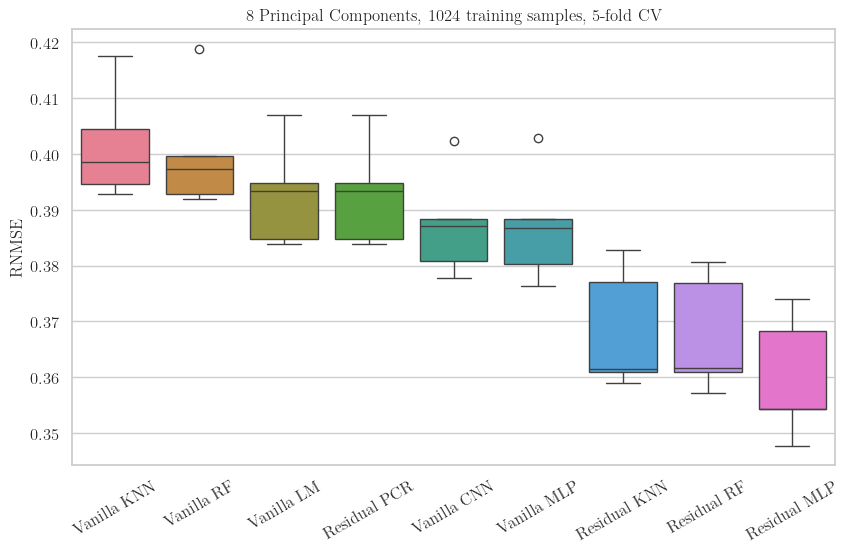

In [55]:
plt.figure(figsize=(9, 6))
plt.title(f"{n_components_pca} Principal Components, {n_points} training samples, {n_cv}-fold CV")
sns.boxplot(data)
plt.ylabel("RNMSE")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('results_small.jpg', dpi=150)
plt.show()